# Failed Generalization of CNN Ice Cream Classifier Trained on Synthetic Dataset

### Abstract

### Research Question & Hypothesis
##### Background, Prior Work


1. Zhang, C., Bengio, S., Hardt, M., Recht, B., & Vinyals, O. (2016). Understanding deep learning requires rethinking generalization.      
https://doi.org/10.48550/arxiv.1611.03530
2. Zhang, C., Bengio, S., Hardt, M., Recht, B., & Vinyals, O. (2021). Understanding deep learning (still) requires rethinking generalization. In Communications of the ACM (Vol. 64, Number 3, pp. 107–115). ACM.       
https://doi.org/10.1145/3446776
3. Arpit, D., Jastrzębski, S., Ballas, N., Krueger, D., Bengio, E., Kanwal, M. S., Maharaj, T., Fischer, A., Courville, A., Bengio, Y., & Lacoste-Julien, S. (2017). A Closer Look at Memorization in Deep Networks.       
https://doi.org/10.48550/arxiv.1706.05394
4. Geirhos, R., Rubisch, P., Michaelis, C., Bethge, M., Wichmann, F. A., & Brendel, W. (2018). ImageNet-trained CNNs are biased towards texture; increasing shape bias improves accuracy and robustness.         
https://doi.org/10.48550/arxiv.1811.12231
5. Recht, B., Roelofs, R., Schmidt, L., & Shankar, V. (2019). Do ImageNet Classifiers Generalize to ImageNet?     
https://doi.org/10.48550/arxiv.1902.10811
6. Geirhos, R., Jacobsen, J.-H., Michaelis, C., Zemel, R., Brendel, W., Bethge, M., & Wichmann, F. A. (2020). Shortcut learning in deep neural networks. Nature Machine Intelligence, 2(11), 665–673.     
https://doi.org/10.1038/s42256-020-00257-z
7. Oliveira, G. C., Rosa, G. H., Pedronette, D. C. G., Papa, J. P., Kumar, H., Passos, L. A., & Kumar, D. (2024). Robust deep learning for eye fundus images: Bridging real and synthetic data for enhancing generalization. arXiv.Org.       
https://doi.org/10.48550/arxiv.2203.13856


##### Hypothesis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import os

from cv2 import imread, cvtColor, resize, COLOR_BGR2RGB
from cv2 import applyColorMap, addWeighted, imwrite, COLORMAP_VIRIDIS

from sklearn.metrics import classification_report
from sklearn.model_selection import KFold, train_test_split
from sklearn.manifold import TSNE

import tensorflow as tf
from keras import layers, models, backend
from keras.models import Sequential, Model, load_model
from keras.layers import Dense, Activation, Dropout
from keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D
from keras.callbacks import EarlyStopping, ModelCheckpoint
from keras.applications.vgg16 import VGG16, preprocess_input

import warnings
warnings.filterwarnings('ignore')

In [2]:
paths = [
    './ConePopsicle/Cone',
    './ConePopsicle/Popsicle']

data = []

for label_idx, path_ in enumerate(paths):
    for filename in os.listdir(path_):
        path = os.path.join(path_, filename)

        im = imread(path)
        im = cvtColor(im, COLOR_BGR2RGB)
        im = resize(im, (128,128)) 

        data.append({
            'image': im.astype(np.float32)/255.0,
            'label': float(label_idx),
            'filename': filename,
            'path': path})

df = pd.DataFrame(data)

X = np.stack(df.image.values)
y = df.label.values

df.head()

,image,label,filename,path
0,"[[[0.07450981, 0.08235294, 0.078431375], [0.07...",0.0,Cone (1).jpg,./ConePopsicle/Cone\Cone (1).jpg
1,"[[[0.3647059, 0.39607844, 0.40392157], [0.3686...",0.0,Cone (10).jpg,./ConePopsicle/Cone\Cone (10).jpg
2,"[[[0.38039216, 0.4392157, 0.46666667], [0.3882...",0.0,Cone (100).jpg,./ConePopsicle/Cone\Cone (100).jpg
3,"[[[0.81960785, 0.5019608, 0.28235295], [0.7843...",0.0,Cone (101).jpg,./ConePopsicle/Cone\Cone (101).jpg
4,"[[[0.9843137, 0.94509804, 0.8980392], [0.98431...",0.0,Cone (102).jpg,./ConePopsicle/Cone\Cone (102).jpg


In [3]:
# Exclude top layer, i.e. classifier, to specify that only the feature
# maps are needed from this particular architecture
model_ = VGG16(
    weights='imagenet', 
    include_top=False, 
    input_shape=(128,128,3))
model = Model(inputs=model_.input, outputs=model_.output)

In [4]:
# Scale images back up for preprocessing
X_tsne_ = X * 255.0
X_tsne = preprocess_input(X_tsne_)

# Generate feature maps then flatten to 1D
features_ = model.predict(X_tsne, batch_size=16, verbose=1)
features = features_.reshape((features_.shape[0], -1))

# Perform t-SNE
tsne_ = TSNE(
    n_components=2, 
    perplexity=30, 
    n_iter=1000, 
    random_state=42)
tsne = tsne_.fit_transform(features)

# Append reduced projection values in the embedded space for each
# image to dataframe for visualization
df['tsne0'] = tsne[:,0]
df['tsne1'] = tsne[:,1]

38/38 [==============================] - 55s 1s/step


In [5]:
def view_cluster(df, x_range, y_range):
    
    # Filter images to instances within the rectangle bound by 
    # chosen axes intervals, i.e. x_range, y_range
    mask0 = (df.tsne0 > x_range[0]) & (df.tsne0 < x_range[1])
    mask1 = (df.tsne1 > y_range[0]) & (df.tsne1 < y_range[1])
    df_cluster = df[mask0 & mask1]
    
    images    = df_cluster.image.values
    labels    = df_cluster.label.values
    filenames = df_cluster.filename.values

    # Limit instances to a maximum of 10
    n = min(len(images),10)
    
    plt.figure(figsize=(20,4))
    for i in range(n):
        plt.subplot(2,10,i+1)
        plt.imshow(images[i])
        plt.title(f'{int(labels[i])} | {filenames[i][:10]}')
        plt.axis('off')

    plt.show()

In [6]:
# Standardize numerical labels to str
map_ = {0.0: 'Cone', 1.0: 'Popsicle'}
df['class'] = df.label.map(map_)

fig = px.scatter(
    df,
    x='tsne0', y='tsne1',
    color='class',
    hover_data=['filename', 'tsne0', 'tsne1'],
    title='t-SNE of Ice Cream Dataset: Class Separability')

marker = dict(size=6, opacity=0.8)
fig.update_traces(marker=marker)

fig.show()

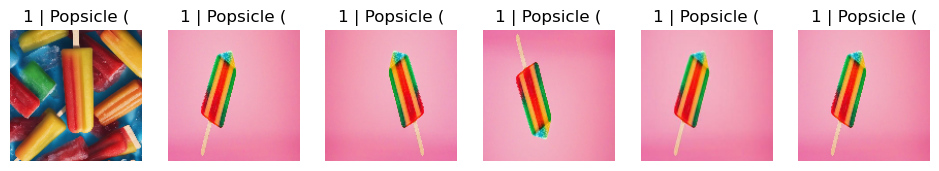

In [9]:
x_range = (-2,0.05)
y_range = (-10,0)

view_cluster(df, x_range=x_range, y_range=y_range)

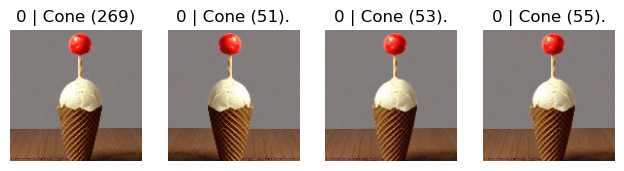

In [7]:
x_range = (-25,-20)
y_range = (49,51)

view_cluster(df, x_range=x_range, y_range=y_range)

In [7]:
def plot_training_curves(history):
    
    acc = history.history['accuracy']
    loss = history.history['loss']
    val_acc = history.history['val_accuracy']
    val_loss = history.history['val_loss']
    
    epochs = range(1,len(acc)+1)

    plt.figure(figsize=(14,5))

    plt.subplot(1,2,1)
    plt.plot(epochs, acc, 'b^', label='Training Accuracy')
    plt.plot(epochs, val_acc, 'b', label='Validation Accuracy')
    plt.title('Training vs. Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(epochs, loss, 'gv', label='Training Loss')
    plt.plot(epochs, val_loss, 'g', label='Validation Loss')
    plt.title('Training vs. Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()




Training fold 1:

Epoch 1: val_loss improved from inf to 0.68309, saving model to models\fold_1.h5

Epoch 2: val_loss improved from 0.68309 to 0.51375, saving model to models\fold_1.h5

Epoch 3: val_loss improved from 0.51375 to 0.26248, saving model to models\fold_1.h5

Epoch 4: val_loss improved from 0.26248 to 0.18897, saving model to models\fold_1.h5

Epoch 5: val_loss improved from 0.18897 to 0.17967, saving model to models\fold_1.h5

Epoch 6: val_loss improved from 0.17967 to 0.17008, saving model to models\fold_1.h5

Epoch 7: val_loss improved from 0.17008 to 0.12018, saving model to models\fold_1.h5

Epoch 8: val_loss did not improve from 0.12018

Epoch 9: val_loss improved from 0.12018 to 0.11162, saving model to models\fold_1.h5

Epoch 10: val_loss did not improve from 0.11162

Epoch 11: val_loss improved from 0.11162 to 0.11115, saving model to models\fold_1.h5

Epoch 12: val_loss did not improve from 0.11115

Epoch 13: val_loss improved from 0.11115 to 0.09980, saving mo

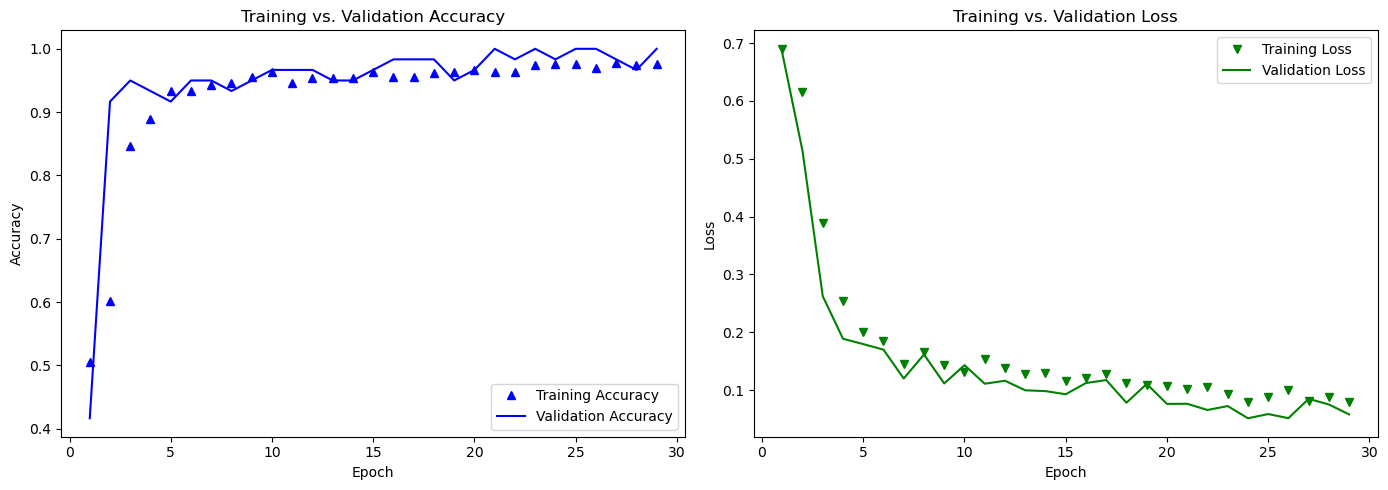

2/2 [==============================] - 0s 29ms/step - loss: 0.0515 - accuracy: 0.9833



Training fold 2:

Epoch 1: val_loss improved from inf to 0.66440, saving model to models\fold_2.h5

Epoch 2: val_loss improved from 0.66440 to 0.52694, saving model to models\fold_2.h5

Epoch 3: val_loss improved from 0.52694 to 0.47314, saving model to models\fold_2.h5

Epoch 4: val_loss improved from 0.47314 to 0.41693, saving model to models\fold_2.h5

Epoch 5: val_loss improved from 0.41693 to 0.34071, saving model to models\fold_2.h5

Epoch 6: val_loss improved from 0.34071 to 0.29758, saving model to models\fold_2.h5

Epoch 7: val_loss improved from 0.29758 to 0.23296, saving model to models\fold_2.h5

Epoch 8: val_loss improved from 0.23296 to 0.22439, saving model to models\fold_2.h5

Epoch 9: val_loss improved from 0.22439 to 0.21388, saving model to models\fold_2.h5

Epoch 10: val_loss improved from 0.21388 to 0.18077, saving model to models\fold_2.h5

Epoch 11: val_loss improved from 0.1

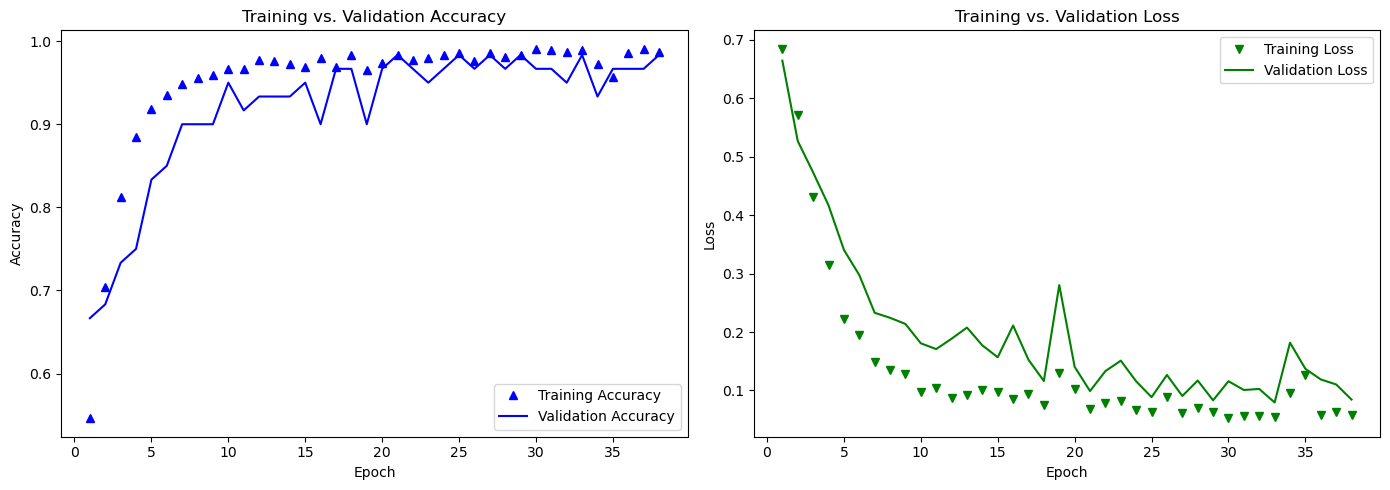

2/2 [==============================] - 0s 32ms/step - loss: 0.0795 - accuracy: 0.9833



Training fold 3:

Epoch 1: val_loss improved from inf to 0.64331, saving model to models\fold_3.h5

Epoch 2: val_loss improved from 0.64331 to 0.44972, saving model to models\fold_3.h5

Epoch 3: val_loss did not improve from 0.44972

Epoch 4: val_loss improved from 0.44972 to 0.22579, saving model to models\fold_3.h5

Epoch 5: val_loss improved from 0.22579 to 0.19661, saving model to models\fold_3.h5

Epoch 6: val_loss improved from 0.19661 to 0.14886, saving model to models\fold_3.h5

Epoch 7: val_loss improved from 0.14886 to 0.10909, saving model to models\fold_3.h5

Epoch 8: val_loss improved from 0.10909 to 0.08559, saving model to models\fold_3.h5

Epoch 9: val_loss did not improve from 0.08559

Epoch 10: val_loss improved from 0.08559 to 0.08073, saving model to models\fold_3.h5

Epoch 11: val_loss did not improve from 0.08073

Epoch 12: val_loss did not improve from 0.08073

Epoch 13: val_

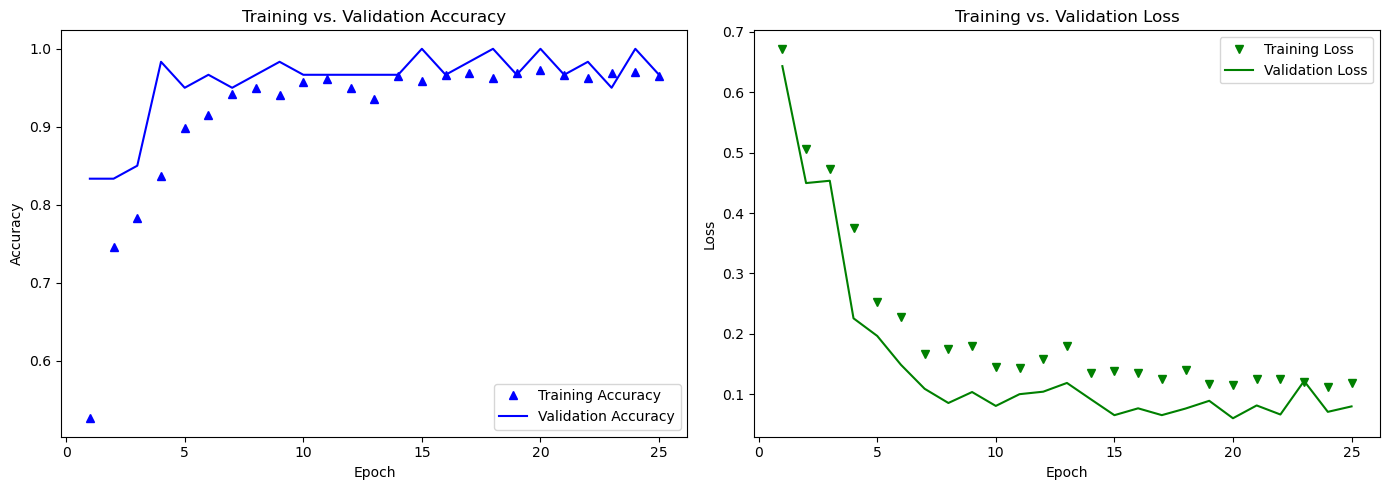

2/2 [==============================] - 0s 26ms/step - loss: 0.0603 - accuracy: 1.0000



Training fold 4:

Epoch 1: val_loss improved from inf to 0.69132, saving model to models\fold_4.h5

Epoch 2: val_loss improved from 0.69132 to 0.67435, saving model to models\fold_4.h5

Epoch 3: val_loss improved from 0.67435 to 0.39639, saving model to models\fold_4.h5

Epoch 4: val_loss improved from 0.39639 to 0.33681, saving model to models\fold_4.h5

Epoch 5: val_loss improved from 0.33681 to 0.25211, saving model to models\fold_4.h5

Epoch 6: val_loss improved from 0.25211 to 0.22861, saving model to models\fold_4.h5

Epoch 7: val_loss improved from 0.22861 to 0.21577, saving model to models\fold_4.h5

Epoch 8: val_loss improved from 0.21577 to 0.20560, saving model to models\fold_4.h5

Epoch 9: val_loss did not improve from 0.20560

Epoch 10: val_loss improved from 0.20560 to 0.18432, saving model to models\fold_4.h5

Epoch 11: val_loss did not improve from 0.18432

Epoch 12: val_loss improv

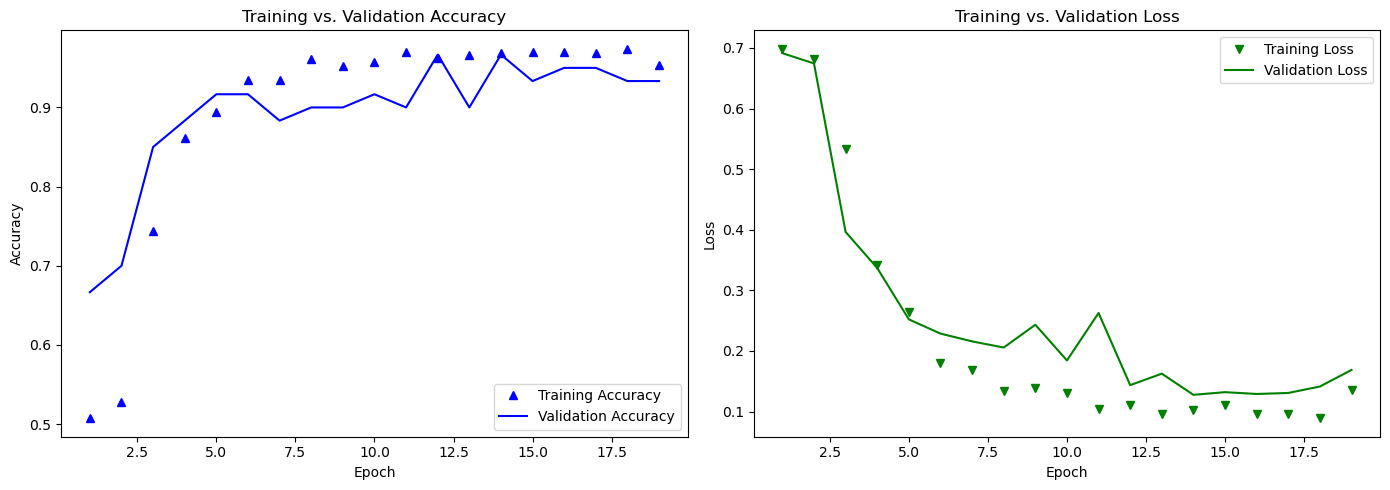

2/2 [==============================] - 0s 22ms/step - loss: 0.1276 - accuracy: 0.9667



Training fold 5:

Epoch 1: val_loss improved from inf to 0.69248, saving model to models\fold_5.h5

Epoch 2: val_loss improved from 0.69248 to 0.68966, saving model to models\fold_5.h5

Epoch 3: val_loss improved from 0.68966 to 0.54433, saving model to models\fold_5.h5

Epoch 4: val_loss improved from 0.54433 to 0.34671, saving model to models\fold_5.h5

Epoch 5: val_loss improved from 0.34671 to 0.21561, saving model to models\fold_5.h5

Epoch 6: val_loss improved from 0.21561 to 0.15101, saving model to models\fold_5.h5

Epoch 7: val_loss did not improve from 0.15101

Epoch 8: val_loss did not improve from 0.15101

Epoch 9: val_loss did not improve from 0.15101

Epoch 10: val_loss improved from 0.15101 to 0.13961, saving model to models\fold_5.h5

Epoch 11: val_loss did not improve from 0.13961

Epoch 12: val_loss did not improve from 0.13961

Epoch 13: val_loss did not improve from 0.13961

Epo

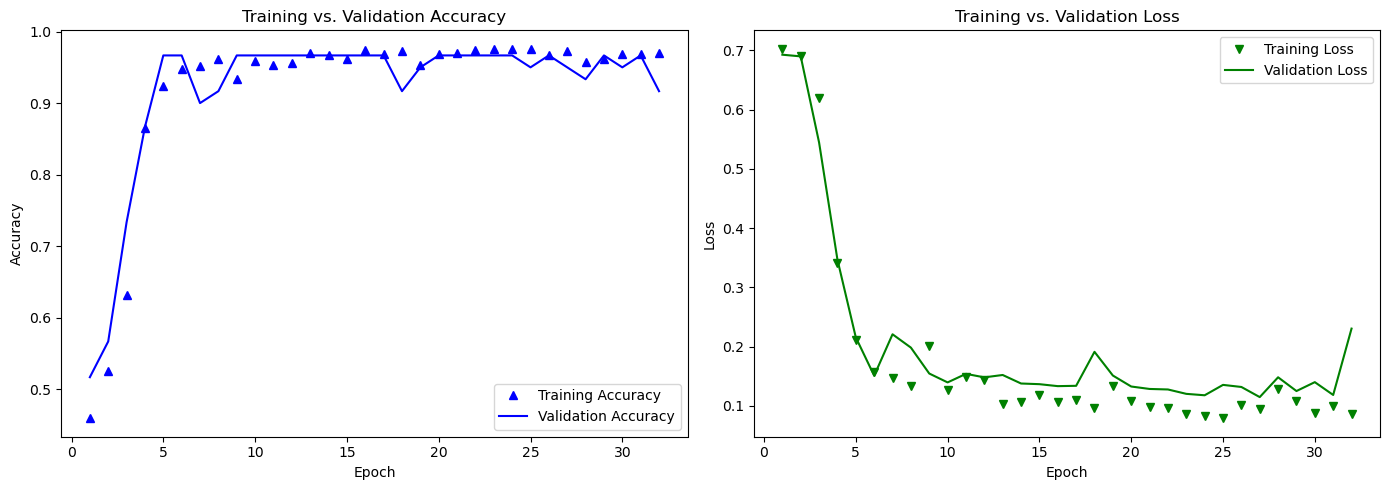

2/2 [==============================] - 0s 21ms/step - loss: 0.1148 - accuracy: 0.9500



Training fold 6:

Epoch 1: val_loss improved from inf to 0.69951, saving model to models\fold_6.h5

Epoch 2: val_loss improved from 0.69951 to 0.57141, saving model to models\fold_6.h5

Epoch 3: val_loss improved from 0.57141 to 0.44365, saving model to models\fold_6.h5

Epoch 4: val_loss improved from 0.44365 to 0.27215, saving model to models\fold_6.h5

Epoch 5: val_loss improved from 0.27215 to 0.23891, saving model to models\fold_6.h5

Epoch 6: val_loss improved from 0.23891 to 0.18519, saving model to models\fold_6.h5

Epoch 7: val_loss did not improve from 0.18519

Epoch 8: val_loss did not improve from 0.18519

Epoch 9: val_loss did not improve from 0.18519

Epoch 10: val_loss improved from 0.18519 to 0.17221, saving model to models\fold_6.h5

Epoch 11: val_loss did not improve from 0.17221

Epoch 12: val_loss did not improve from 0.17221

Epoch 13: val_loss did not improve from 0.17221

Epo

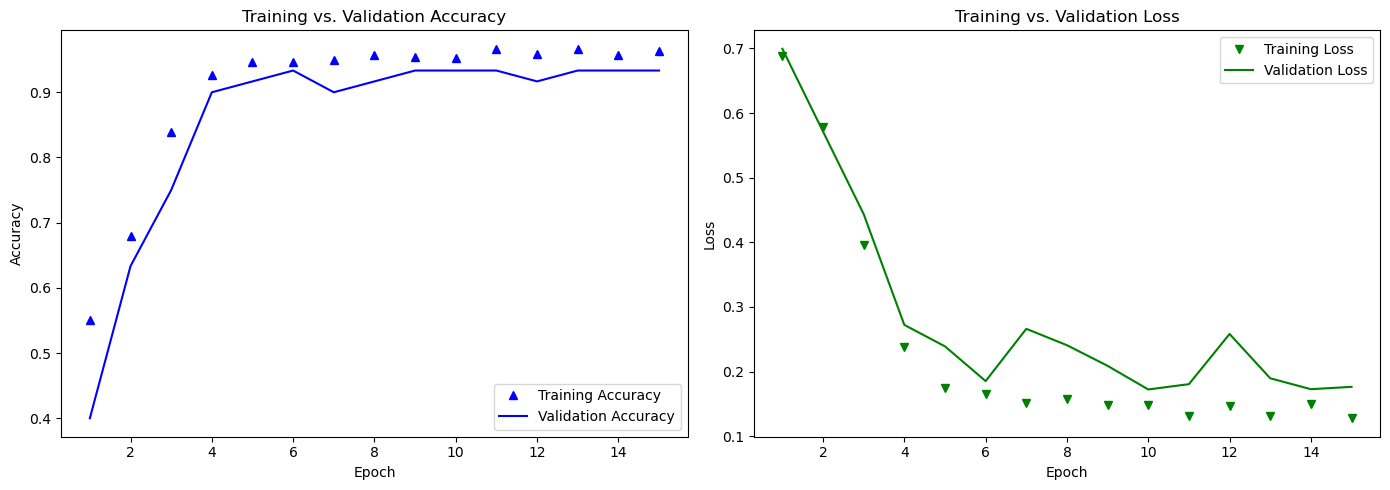

2/2 [==============================] - 1s 159ms/step - loss: 0.1722 - accuracy: 0.9333



Training fold 7:

Epoch 1: val_loss improved from inf to 0.58567, saving model to models\fold_7.h5

Epoch 2: val_loss improved from 0.58567 to 0.29344, saving model to models\fold_7.h5

Epoch 3: val_loss improved from 0.29344 to 0.26116, saving model to models\fold_7.h5

Epoch 4: val_loss improved from 0.26116 to 0.25266, saving model to models\fold_7.h5

Epoch 5: val_loss improved from 0.25266 to 0.25005, saving model to models\fold_7.h5

Epoch 6: val_loss improved from 0.25005 to 0.24334, saving model to models\fold_7.h5

Epoch 7: val_loss improved from 0.24334 to 0.23944, saving model to models\fold_7.h5

Epoch 8: val_loss improved from 0.23944 to 0.22993, saving model to models\fold_7.h5

Epoch 9: val_loss improved from 0.22993 to 0.20968, saving model to models\fold_7.h5

Epoch 10: val_loss improved from 0.20968 to 0.18244, saving model to models\fold_7.h5

Epoch 11: val_loss improved from 0.

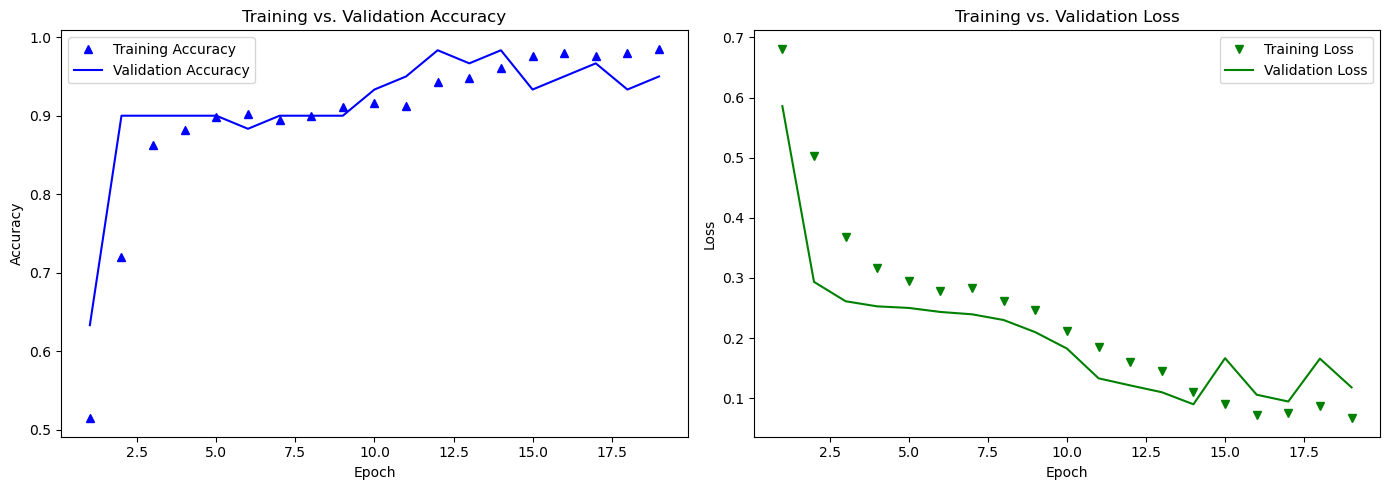

2/2 [==============================] - 0s 27ms/step - loss: 0.0898 - accuracy: 0.9833



Training fold 8:

Epoch 1: val_loss improved from inf to 0.68932, saving model to models\fold_8.h5

Epoch 2: val_loss improved from 0.68932 to 0.54910, saving model to models\fold_8.h5

Epoch 3: val_loss improved from 0.54910 to 0.38201, saving model to models\fold_8.h5

Epoch 4: val_loss improved from 0.38201 to 0.15531, saving model to models\fold_8.h5

Epoch 5: val_loss did not improve from 0.15531

Epoch 6: val_loss improved from 0.15531 to 0.14838, saving model to models\fold_8.h5

Epoch 7: val_loss improved from 0.14838 to 0.13287, saving model to models\fold_8.h5

Epoch 8: val_loss did not improve from 0.13287

Epoch 9: val_loss improved from 0.13287 to 0.11682, saving model to models\fold_8.h5

Epoch 10: val_loss improved from 0.11682 to 0.11226, saving model to models\fold_8.h5

Epoch 11: val_loss improved from 0.11226 to 0.10976, saving model to models\fold_8.h5

Epoch 12: val_loss improv

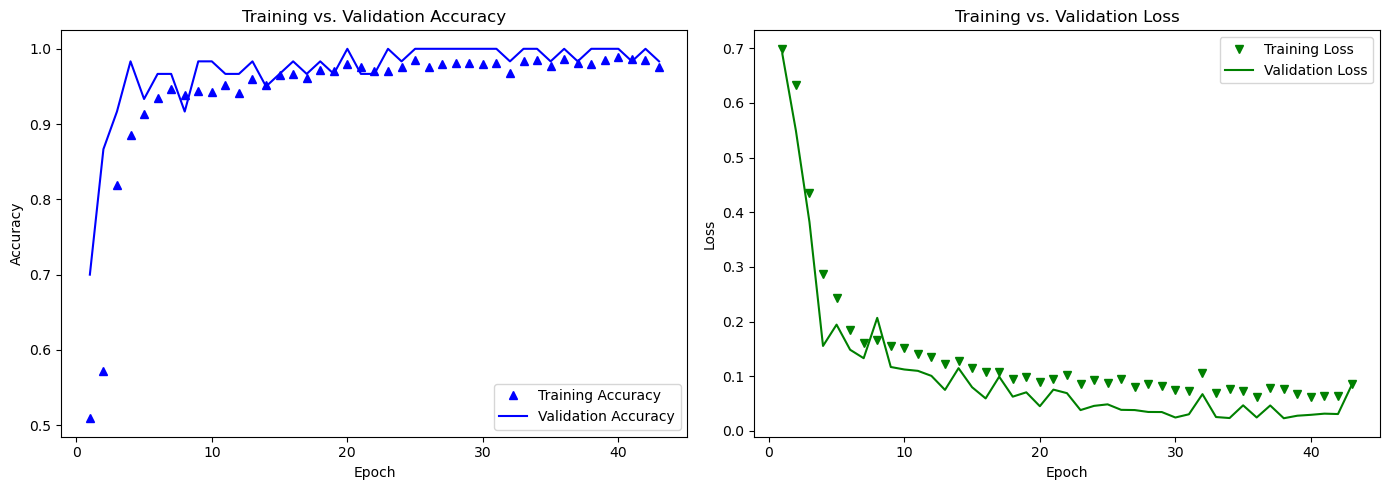

2/2 [==============================] - 0s 142ms/step - loss: 0.0230 - accuracy: 1.0000



Training fold 9:

Epoch 1: val_loss improved from inf to 0.69108, saving model to models\fold_9.h5

Epoch 2: val_loss improved from 0.69108 to 0.64240, saving model to models\fold_9.h5

Epoch 3: val_loss improved from 0.64240 to 0.41969, saving model to models\fold_9.h5

Epoch 4: val_loss improved from 0.41969 to 0.21667, saving model to models\fold_9.h5

Epoch 5: val_loss improved from 0.21667 to 0.17565, saving model to models\fold_9.h5

Epoch 6: val_loss improved from 0.17565 to 0.14187, saving model to models\fold_9.h5

Epoch 7: val_loss improved from 0.14187 to 0.12875, saving model to models\fold_9.h5

Epoch 8: val_loss improved from 0.12875 to 0.12680, saving model to models\fold_9.h5

Epoch 9: val_loss improved from 0.12680 to 0.11191, saving model to models\fold_9.h5

Epoch 10: val_loss did not improve from 0.11191

Epoch 11: val_loss improved from 0.11191 to 0.10708, saving model to mode

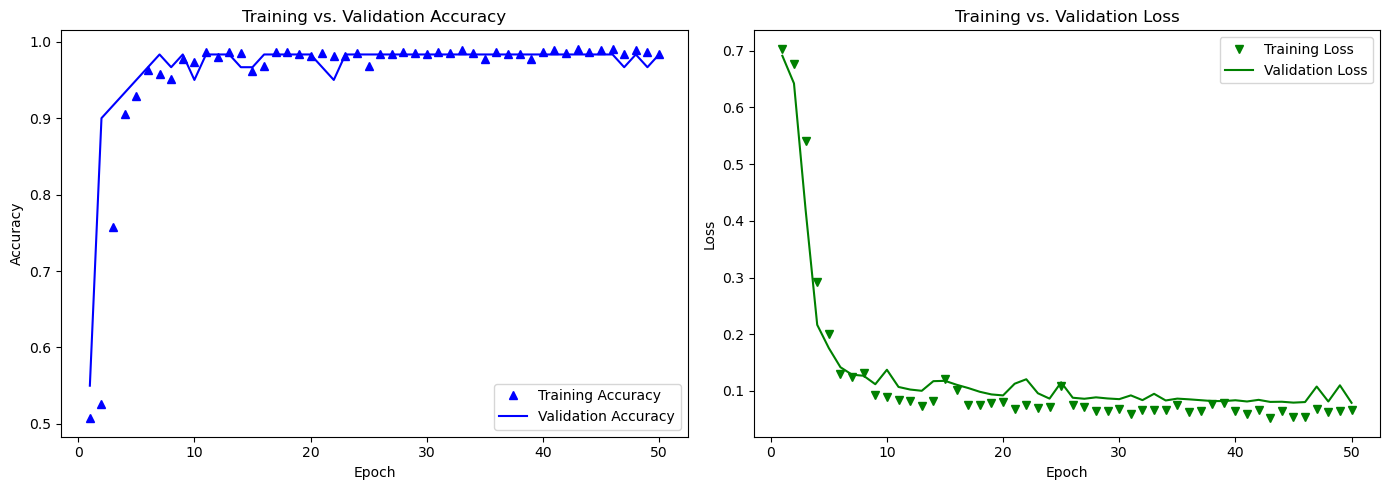

2/2 [==============================] - 0s 174ms/step - loss: 0.0791 - accuracy: 0.9833



Training fold 10:

Epoch 1: val_loss improved from inf to 0.68225, saving model to models\fold_10.h5

Epoch 2: val_loss improved from 0.68225 to 0.59970, saving model to models\fold_10.h5

Epoch 3: val_loss improved from 0.59970 to 0.40314, saving model to models\fold_10.h5

Epoch 4: val_loss did not improve from 0.40314

Epoch 5: val_loss improved from 0.40314 to 0.29080, saving model to models\fold_10.h5

Epoch 6: val_loss improved from 0.29080 to 0.28038, saving model to models\fold_10.h5

Epoch 7: val_loss did not improve from 0.28038

Epoch 8: val_loss improved from 0.28038 to 0.24980, saving model to models\fold_10.h5

Epoch 9: val_loss did not improve from 0.24980

Epoch 10: val_loss improved from 0.24980 to 0.17029, saving model to models\fold_10.h5

Epoch 11: val_loss improved from 0.17029 to 0.16725, saving model to models\fold_10.h5

Epoch 12: val_loss did not improve from 0.16725

Epoc

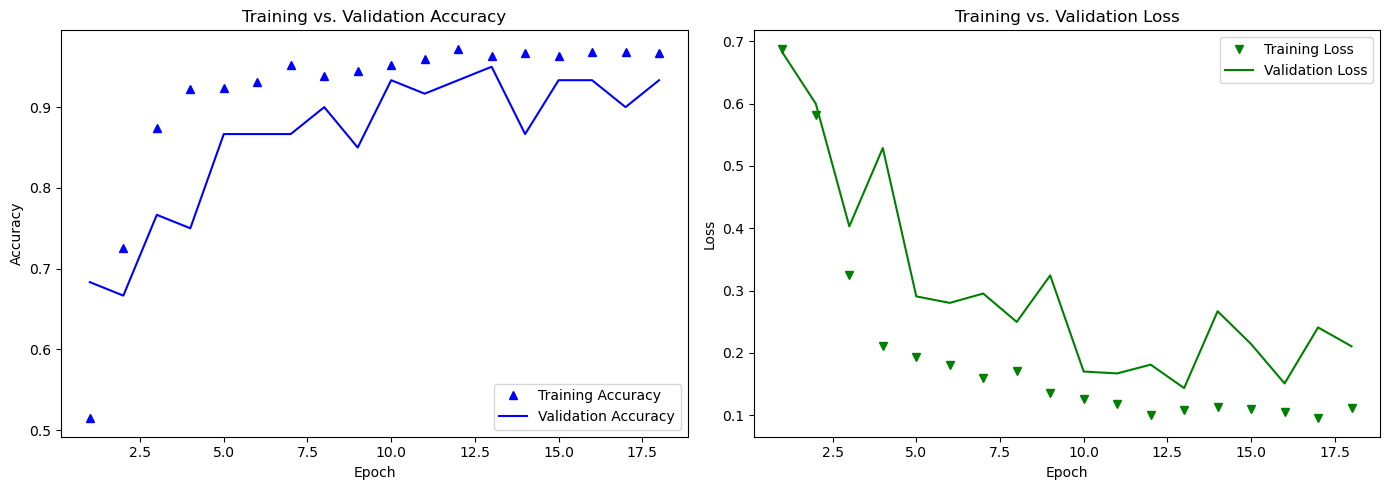

2/2 [==============================] - 0s 34ms/step - loss: 0.1437 - accuracy: 0.9500

Cross-validation results:
Mean accuracy  : 97.33%
Mean loss      : 0.0942
Fold Accuracies:  [ 98.33  98.33 100.    96.67  95.    93.33  98.33 100.    98.33  95.  ]


In [10]:
os.makedirs('models', exist_ok=True)

kfold = KFold(
    n_splits=10, 
    shuffle=True,
    random_state=42)

fold = 1
fold_acc, fold_loss = [],[]

for t_i, v_i in kfold.split(X,y):
    print(f'\n\n\nTraining fold {fold}:')
    
    X_t, X_v = X[t_i], X[v_i]
    y_t, y_v = y[t_i], y[v_i]
    
    
    model = Sequential()
    
    model.add(Conv2D(8, (3,3), input_shape=(128,128,3)))
    model.add(Activation('relu'))
    model.add(MaxPooling2D((2,2)))
    model.add(Dropout(0.3))
    
    model.add(Conv2D(16, (3,3)))
    #model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D((2,2)))
    model.add(Dropout(0.3))
    
    model.add(Conv2D(32, (3,3)))
    #model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D((2,2)))
    model.add(Dropout(0.3))
    
    model.add(Conv2D(64, (3,3)))
    model.add(Activation('relu'))
    model.add(GlobalAveragePooling2D())
    model.add(Dropout(0.3))
    
    model.add(Dense(64, activation='relu'))
    
    model.add(Dense(1, activation='sigmoid'))
    
    
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy'])

    
    stopping = EarlyStopping(
        monitor='val_loss', 
        patience=5, 
        restore_best_weights=True)
    
    checkpoint = ModelCheckpoint(
        filepath=f"models/fold_{fold}.h5",
        monitor='val_loss',
        save_best_only=True,
        verbose=1)
    
    
    history = model.fit(
        X_t, y_t, 
        epochs=50,
        batch_size=16,
        validation_data=(X_v,y_v),
        verbose=0,
        callbacks=[stopping, checkpoint])
    
    plot_training_curves(history)
    
    scores = model.evaluate(X_v, y_v, verbose=1)
    
    fold_acc.append(scores[1])
    fold_loss.append(scores[0])
    fold = fold + 1
    
    
print('\nCross-validation results:')
print('Mean accuracy  : {:.2f}%'.format(np.mean(fold_acc)*100))
print('Mean loss      : {:.4f}'.format(np.mean(fold_loss)))
print('Fold Accuracies: ', np.round(np.array(fold_acc)*100, 2))

In [21]:
X_, X_tt, y_, y_tt = train_test_split(
    X, y,
    test_size=0.15,
    random_state=42,
    stratify=y)

X_t, X_v, y_t, y_v = train_test_split(
    X_, y_,
    test_size=0.1765,
    random_state=42,
    stratify=y_)

print(f'Set sizes\nTraining  : {X_t.shape}\nTest      : {X_tt.shape}\nValidation: {X_v.shape}')

Set sizes
Training  : (419, 128, 128, 3)
Test      : (90, 128, 128, 3)
Validation: (91, 128, 128, 3)


Epoch 1/50
26/27 [===========================>..] - ETA: 0s - loss: 0.7047 - accuracy: 0.4639
Epoch 1: val_loss improved from inf to 0.69251, saving model to model_final.h5
27/27 [==============================] - 9s 193ms/step - loss: 0.7049 - accuracy: 0.4630 - val_loss: 0.6925 - val_accuracy: 0.4945
Epoch 2/50
26/27 [===========================>..] - ETA: 0s - loss: 0.6915 - accuracy: 0.5096
Epoch 2: val_loss improved from 0.69251 to 0.69026, saving model to model_final.h5
27/27 [==============================] - 6s 214ms/step - loss: 0.6916 - accuracy: 0.5084 - val_loss: 0.6903 - val_accuracy: 0.6044
Epoch 3/50
26/27 [===========================>..] - ETA: 0s - loss: 0.6476 - accuracy: 0.5889
Epoch 3: val_loss improved from 0.69026 to 0.60604, saving model to model_final.h5
27/27 [==============================] - 3s 105ms/step - loss: 0.6468 - accuracy: 0.5895 - val_loss: 0.6060 - val_accuracy: 0.7253
Epoch 4/50
26/27 [===========================>..] - ETA: 0s - loss: 0.5039 - acc

27/27 [==============================] - 2s 70ms/step - loss: 0.0512 - accuracy: 0.9905 - val_loss: 0.1479 - val_accuracy: 0.9560
Epoch 30/50
27/27 [==============================] - ETA: 0s - loss: 0.0778 - accuracy: 0.9714
Epoch 30: val_loss did not improve from 0.09904
27/27 [==============================] - 2s 64ms/step - loss: 0.0778 - accuracy: 0.9714 - val_loss: 0.2073 - val_accuracy: 0.9341
Epoch 31/50
26/27 [===========================>..] - ETA: 0s - loss: 0.0689 - accuracy: 0.9856
Epoch 31: val_loss did not improve from 0.09904
27/27 [==============================] - 2s 75ms/step - loss: 0.0684 - accuracy: 0.9857 - val_loss: 0.1309 - val_accuracy: 0.9560
Epoch 32/50
26/27 [===========================>..] - ETA: 0s - loss: 0.0510 - accuracy: 0.9952
Epoch 32: val_loss did not improve from 0.09904
27/27 [==============================] - 2s 75ms/step - loss: 0.0507 - accuracy: 0.9952 - val_loss: 0.1323 - val_accuracy: 0.9560
Epoch 33/50
27/27 [==============================] 

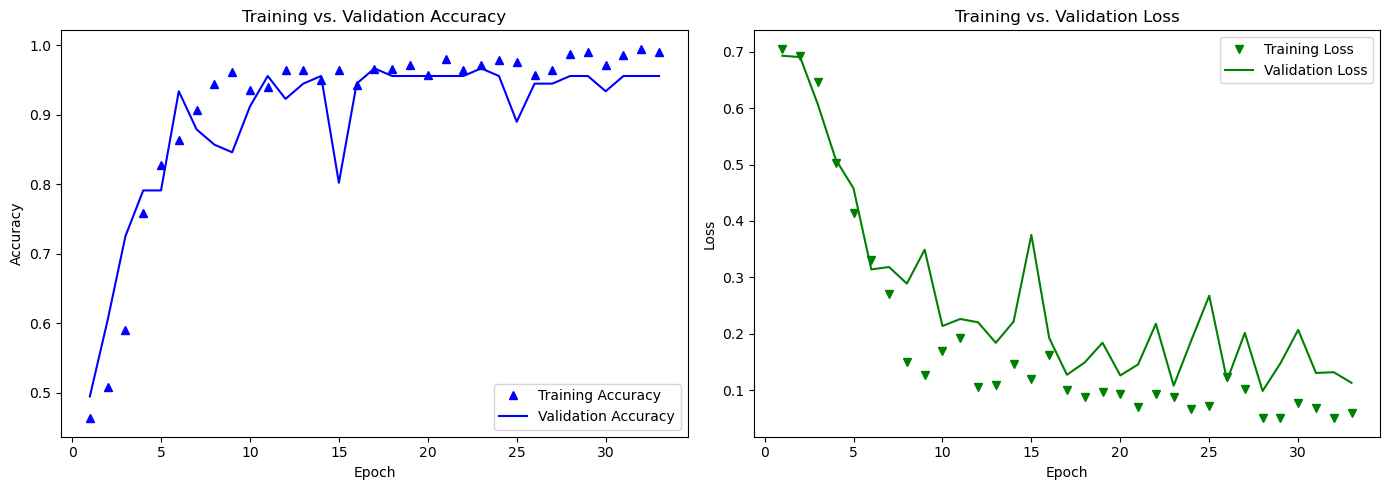

In [22]:
model = Sequential()

model.add(Conv2D(8, (3,3), input_shape=(128,128,3)))
model.add(Activation('relu'))
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.3))

model.add(Conv2D(16, (3,3)))
#model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.3))

model.add(Conv2D(32, (3,3)))
#model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.3))

model.add(Conv2D(64, (3,3)))
model.add(Activation('relu'))
model.add(GlobalAveragePooling2D())
model.add(Dropout(0.3))

model.add(Dense(64, activation='relu'))

model.add(Dense(1, activation='sigmoid'))


model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy'])


stopping = EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True)

checkpoint = ModelCheckpoint(
    'model_final.h5',
    monitor='val_loss',
    save_best_only=True,
    verbose=1)


history = model.fit(
    X_t, y_t, 
    epochs=50,
    batch_size=16,
    validation_data=(X_v,y_v),
    verbose=1,
    callbacks=[stopping, checkpoint])

plot_training_curves(history)

In [23]:
model.summary()

Model: "sequential_30"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_120 (Conv2D)         (None, 126, 126, 8)       224       
                                                                 
 activation_120 (Activation)  (None, 126, 126, 8)      0         
                                                                 
 max_pooling2d_90 (MaxPoolin  (None, 63, 63, 8)        0         
 g2D)                                                            
                                                                 
 dropout_120 (Dropout)       (None, 63, 63, 8)         0         
                                                                 
 conv2d_121 (Conv2D)         (None, 61, 61, 16)        1168      
                                                                 
 activation_121 (Activation)  (None, 61, 61, 16)       0         
                                                     

In [24]:
model = load_model('model_final.h5')

test_loss, test_acc = model.evaluate(X_tt, y_tt, verbose=1)
predictions_y = (model.predict(X_tt) > 0.5).astype(int)

print(classification_report(y_tt, predictions_y, target_names=['Cone', 'Popsicle']))

3/3 [==============================] - 0s 23ms/step
              precision    recall  f1-score   support

        Cone       0.94      1.00      0.97        45
    Popsicle       1.00      0.93      0.97        45

    accuracy                           0.97        90
   macro avg       0.97      0.97      0.97        90
weighted avg       0.97      0.97      0.97        90



In [28]:
filenames = [f'test_img_{i}.jpg' for i in range(len(X_tt))]

df_test = pd.DataFrame({
    'image'   : list(X_tt),
    'filename': filenames,
    'label'   : y_tt.astype(np.float32)})

df_test.head()

,image,filename,label
0,"[[[0.15686275, 0.12156863, 0.101960786], [0.19...",test_img_0.jpg,0.0
1,"[[[0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [0.0, 0.0,...",test_img_1.jpg,0.0
2,"[[[0.49019608, 0.5058824, 0.5529412], [0.49803...",test_img_2.jpg,1.0
3,"[[[0.23137255, 0.20784314, 0.20784314], [0.239...",test_img_3.jpg,0.0
4,"[[[0.011764706, 0.6745098, 0.74509805], [0.0, ...",test_img_4.jpg,1.0


In [33]:
def gradcam(image, model, write=None, alpha=0.75):

    last_conv_layer = None
    for layer in reversed(model.layers):
        if isinstance(layer, Conv2D):
            last_conv_layer = layer.name
            break

    model_gc = Model(
        [model.inputs], 
        [model.get_layer(last_conv_layer).output, model.output])

    with tf.GradientTape() as tape:
        conv_outputs, predictions = model_gc(image)
        predictions_idx = tf.argmax(predictions[0])
        channel = predictions[:, predictions_idx]

    gradients = tape.gradient(channel, conv_outputs)
    gradients_pooled = tf.reduce_mean(gradients, axis=(0,1,2))

    conv_outputs = conv_outputs[0]
    heatmap_ = conv_outputs @ gradients_pooled[..., tf.newaxis]
    heatmap_ = tf.squeeze(heatmap_)
    heatmap_ = tf.maximum(heatmap_,0)/tf.math.reduce_max(heatmap_+1e-6)
    heatmap_ = heatmap_.numpy()

    im = np.uint8(image.squeeze()*255)
    if im.shape[-1] == 1:
        im = np.repeat(im,3,axis=-1)

    heatmap_ = resize(heatmap_, (im.shape[1], im.shape[0]))
    heatmap = applyColorMap(np.uint8(heatmap_*255), COLORMAP_VIRIDIS)
    
    img = addWeighted(im, 1-alpha, heatmap, alpha, 0)
    
    if write:
        imwrite(write, img)

    return img, predictions.numpy()[0][0]

In [34]:
os.makedirs('gradcam', exist_ok=True)

predictions = []
for i in range(len(X_tt)):
    image = np.expand_dims(X_tt[i], axis=0)
    write = f'gradcam_test_outputs/gradcam_{i}.jpg'
    _, score = gradcam(image, model, write)
    predictions.append(score)
    
logs = []
for i, score in enumerate(predictions): 
    
    pred_label = 1 if score >= 0.5 else 0
    true_label = int(y_tt[i])
    
    logs.append({
        'index': i,
        'filename': f'gradcam_{i}.jpg',
        'true_label': true_label,
        'pred_label': pred_label,
        'pred_score': round(score,4),
        'is_correct': pred_label==true_label})

df_logs = pd.DataFrame(logs)

In [35]:
df_logs[df_logs.is_correct == False]

,index,filename,true_label,pred_label,pred_score,is_correct
55,55,gradcam_55.jpg,1,0,0.0187,False
56,56,gradcam_56.jpg,1,0,0.0193,False
76,76,gradcam_76.jpg,1,0,0.0183,False


In [38]:
def load_real_images(folder, label, size=(128,128)):
    
    images, labels, names = [],[],[]
    
    for f in os.listdir(folder):
        path = os.path.join(folder, f)
        
        im = imread(path)
        if im is not None:
            im = cvtColor(im, COLOR_BGR2RGB)
            im = resize(im, size)
            
            images.append(im.astype(np.float32)/255.0)
            labels.append(label)
            names.append(f)
            
    return images, labels, names

In [39]:
cone, y_cone, name_cone = load_real_images('./ConePopsicle/Real/Cone', 0)
pops, y_pops, name_pops = load_real_images('./ConePopsicle/Real/Popsicle', 1)

X_real = np.array(cone + pops)
y_real = np.array(y_cone + y_pops)
name_real = name_cone + name_pops

In [40]:
score = model.evaluate(X_real, y_real, verbose=1)
acc = score[1]
print(f'Real-world accuracy: {acc:.2%}')

2/2 [==============================] - 0s 21ms/step - loss: 2.1624 - accuracy: 0.6200
Real-world accuracy: 62.00%
